# INSTALL REQUIREMENT PACKAGES

In [7]:
# !pip install -r setup_files/requirements.txt

In [1]:
import google.generativeai as genai
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, balanced_accuracy_score
from tqdm.notebook import tqdm
import os
import time
import re
import collections
import emoji 
from vncorenlp import VnCoreNLP
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import tensorflow as tf

# DATA PROCESSING

In [3]:
# Load dataset
data_raw = pd.read_csv("Data/Visocial mh dataset.csv")
data_raw.head()

,text,label tay,label chatgpt,label,keyword của mình,keyword của chatgpt,Reason của mình,Reason của chatgpt,từ viết tắt
0,người yêu mình vẫn còn tình cảm với người cũ c...,0,1,0,NaN,"buồn, hụt hẫng",NaN,Tình yêu,"fb, tus, react"
1,Xin tips giảm overthinking khi quen bạn trai í...,1,1,1,overthinking,overthinking,Tâm lý cá nhân,Tâm lý cá nhân,"mqh, overthinking"
2,Mng cho em câu trả lời với...\nEm có một người...,0,0,0,NaN,NaN,NaN,NaN,"nhma, Mng, ntn"
3,Cuối năm mà tiêu cực quá mn ơi 😢. \nThời điểm ...,1,1,1,"tiêu cực, hướng nội, cô lập, stress","tiêu cực, hướng nội, cô lập, stress",Tâm lý cá nhân,Tâm lý cá nhân,"mn, k,e,cx, cty, stress"
4,LÀM SAO CÓ THỂ NÓI NHIỀU ?\nTừ những năm cấp 2...,0,1,0,NaN,"im lặng, né tránh, sự tự ti",NaN,Tâm lý cá nhân,ko


In [4]:
# Bỏ cột không cần thiết
columns_to_drop = ['label tay', 'label chatgpt', 'keyword của mình', 'keyword của chatgpt', 'từ viết tắt']
data = data_raw.drop(columns=columns_to_drop, inplace=True)
print("dropped")

dropped


In [6]:
def normalize_repeated_words(text):
    if not isinstance(text, str): # Thêm kiểm tra kiểu
        return text 
    normalized_text = re.sub(r'(\w)(\1{2,})', r'\1', text)
    return normalized_text

def remove_non_alphanumeric(text):
    if not isinstance(text, str): # Thêm kiểm tra kiểu
        return text 
    allowed_characters = r'[^\w\sA-Za-zÀÁẮẤẰẦẢẲẨÃẴẪẠẶẬĐEÊÉẾÈỀẺỂẼỄẸỆIÍÌỈĨỊOÔƠÓỐỚÒỒỜỎỔỞÕỖỠỌỘỢUƯÚỨÙỪỦỬŨỮỤỰYÝỲỶỸỴa-z0-9.,\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF.]+'
    return re.sub(allowed_characters, '', text)

def remove_special_characters(text):
    special_characters = r'[\x00-\x1F\x7F' + \
                         r'!"#$%&\'()*+,-./:;<=>?@[\\]^_{|}~' + \
                         r'¢£¥€©®™“”‘’–\/‒—ñàáâäçßæøÿ]'
    # Chuyển None thành 'None', NaN thành 'nan'
    clean_text = str(text)
    # Xử lý dấu ba chấm trước (tùy chọn)
    clean_text = re.sub(r'\.\.\.', '...', clean_text)
    # Loại bỏ các ký tự đặc biệt khác
    clean_text = re.sub(special_characters, '', clean_text)
    # Có thể thêm chuẩn hóa khoảng trắng ở đây
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()
    return clean_text

def build_dictionary_from_file(file_path):
    abbreviation_dict = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                line = line.strip()
                if line:
                    parts = line.split(',')
                    if len(parts) == 2:
                        abbreviation, full_form = map(str.strip, parts)
                        abbreviation_dict[abbreviation] = full_form
        print(f"Đã đọc thành công từ điển viết tắt từ: {file_path}")
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file từ điển viết tắt tại: {file_path}")
    except Exception as e:
        print(f"Lỗi khi đọc file từ điển: {e}")
    return abbreviation_dict

def expand_abbr(text, abbr_dict):
    if not isinstance(text, str): # Thêm kiểm tra kiểu
        return text # hoặc return ""
    words = text.split()
    expanded_words = [abbr_dict.get(word, word) for word in words]
    return ' '.join(expanded_words)


# --- Xử lý giá trị thiếu và chuyển đổi kiểu ---
print("Xử lý giá trị thiếu và chuyển đổi kiểu cột 'text'...")
data['text'].fillna('', inplace=True)
print("Cột 'text' sau khi xử lý NaN (ví dụ 5 dòng đầu):")
print(data['text'].head())


# --- Xây dựng từ điển ---
abbreviations_path = ("Data/abbreviate.txt") 
abbr = build_dictionary_from_file(abbreviations_path)
if not abbr:
     print("Cảnh báo: Từ điển viết tắt rỗng. Bước expand_abbr sẽ không có tác dụng.")

# --- Áp dụng các hàm tiền xử lý ---
print("\nBắt đầu áp dụng các hàm tiền xử lý...")

# 1. Lowercase
data['text'] = data['text'].astype(str).str.lower()
print("1. Đã chuyển sang chữ thường.")

# 2. Clean Characters
data['text'] = data['text'].apply(remove_special_characters)
print("2. Đã loại bỏ ký tự đặc biệt (dùng remove_special_characters).")

# 3. Expand Abbreviations
data['text'] = data['text'].apply(lambda x: expand_abbr(x, abbr))
print("3. Đã mở rộng từ viết tắt.")

# 4. Normalize Repeated Words
data['text'] = data['text'].apply(normalize_repeated_words)
print("4. Đã chuẩn hóa từ lặp.")

# 5. (Optional) Remove extra whitespace again
data['text'] = data['text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip() if isinstance(x, str) else x)
print("5. Đã loại bỏ khoảng trắng thừa cuối cùng.")


print("\nHoàn thành tiền xử lý. 5 dòng đầu của cột 'text' đã xử lý:")
print(data['text'].head())

Tải dữ liệu thành công.
Xử lý giá trị thiếu và chuyển đổi kiểu cột 'text'...
Cột 'text' sau khi xử lý NaN (ví dụ 5 dòng đầu):
0    người yêu mình vẫn còn tình cảm với người cũ c...
1    Xin tips giảm overthinking khi quen bạn trai í...
2    Mng cho em câu trả lời với...\nEm có một người...
3    Cuối năm mà tiêu cực quá mn ơi 😢. \nThời điểm ...
4    LÀM SAO CÓ THỂ NÓI NHIỀU ?\nTừ những năm cấp 2...
Name: text, dtype: object
Đã đọc thành công từ điển viết tắt từ: Data/abbreviate.txt

Bắt đầu áp dụng các hàm tiền xử lý...
1. Đã chuyển sang chữ thường.
2. Đã loại bỏ ký tự đặc biệt (dùng remove_special_characters).


C:\Users\Nhi\AppData\Local\Temp\ipykernel_7984\2333115714.py:79: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['text'].fillna('', inplace=True)


3. Đã mở rộng từ viết tắt.
4. Đã chuẩn hóa từ lặp.
5. Đã loại bỏ khoảng trắng thừa cuối cùng.

Hoàn thành tiền xử lý. 5 dòng đầu của cột 'text' đã xử lý:
0    người yêu mình vẫn còn tình cảm với người cũ c...
1    xin cách làm giảm suy nghĩ nhiều học kỳ quen b...
2    mọi người cho em câu trả lời với... em có một ...
3    cuối năm mà tiêu cực quá mọi người ơi 😢. thời ...
4    làm sao có thể nói nhiều ? từ những năm cấp 2,...
Name: text, dtype: object


In [7]:
# Create a boolean mask for rows that contain emojis
emoji_mask = data['text'].apply(lambda text: bool(emoji.emoji_list(text)))

# Use the mask to filter the DataFrame and show only the rows that have emojis
emoji_row = data[emoji_mask]
emoji_row

,text,label tay,label chatgpt,label,keyword của mình,keyword của chatgpt,Reason của mình,Reason của chatgpt,từ viết tắt
1,xin cách làm giảm suy nghĩ nhiều học kỳ quen b...,1,1,1,overthinking,overthinking,Tâm lý cá nhân,Tâm lý cá nhân,"mqh, overthinking"
3,cuối năm mà tiêu cực quá mọi người ơi 😢. thời ...,1,1,1,"tiêu cực, hướng nội, cô lập, stress","tiêu cực, hướng nội, cô lập, stress",Tâm lý cá nhân,Tâm lý cá nhân,"mn, k,e,cx, cty, stress"
4,"làm sao có thể nói nhiều ? từ những năm cấp 2,...",0,1,0,NaN,"im lặng, né tránh, sự tự ti",NaN,Tâm lý cá nhân,ko
6,tớ thấy mọi người trong này bị trầm cảm rồi đấ...,0,0,0,NaN,NaN,NaN,NaN,"nt, cr, comment, crush"
7,mọi người cho mình xin ý kiến với. mình và say...,0,0,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
988,dạo này mình bị tiêu cực qá 🥹 mình vừa tốt ngh...,0,0,0,NaN,NaN,NaN,NaN,NaN
989,có chuyện này mình cứ suy nghĩ mãi có phải mìn...,0,0,0,NaN,NaN,NaN,NaN,NaN
991,mọi người ơi có cách nào để bớt suy nghĩ không...,1,1,1,"tiêu cực, thấy mình vô cùng thất \nbại và tệ, ...","""áp lực công việc"", ""suy nghĩ tiêu cực""",Tâm lý cá nhân,Tâm lý cá nhân,"sale, top"
995,"không biết sao nữa , cứ mỗi lần lạc lõng như n...",0,0,0,NaN,NaN,NaN,NaN,NaN


In [11]:
data['emoji to text'] = data['text'].apply(emoji.demojize)
data.head()

,text,label tay,label chatgpt,label,keyword của mình,keyword của chatgpt,Reason của mình,Reason của chatgpt,từ viết tắt,emoji to text
0,người yêu mình vẫn còn tình cảm với người cũ c...,0,1,0,NaN,"buồn, hụt hẫng",NaN,Tình yêu,"fb, tus, react",người yêu mình vẫn còn tình cảm với người cũ c...
1,xin cách làm giảm suy nghĩ nhiều học kỳ quen b...,1,1,1,overthinking,overthinking,Tâm lý cá nhân,Tâm lý cá nhân,"mqh, overthinking",xin cách làm giảm suy nghĩ nhiều học kỳ quen b...
2,mọi người cho em câu trả lời với... em có một ...,0,0,0,NaN,NaN,NaN,NaN,"nhma, Mng, ntn",mọi người cho em câu trả lời với... em có một ...
3,cuối năm mà tiêu cực quá mọi người ơi 😢. thời ...,1,1,1,"tiêu cực, hướng nội, cô lập, stress","tiêu cực, hướng nội, cô lập, stress",Tâm lý cá nhân,Tâm lý cá nhân,"mn, k,e,cx, cty, stress",cuối năm mà tiêu cực quá mọi người ơi :crying_...
4,"làm sao có thể nói nhiều ? từ những năm cấp 2,...",0,1,0,NaN,"im lặng, né tránh, sự tự ti",NaN,Tâm lý cá nhân,ko,"làm sao có thể nói nhiều ? từ những năm cấp 2,..."


In [12]:
# Đọc danh sách stop words từ file vietnamese_stopword.txt
with open('Data/vietnamese-stopwords.txt', 'r', encoding='utf-8') as file:
    stop_words = set([word.strip() for word in file.readlines()])
# Hàm để loại bỏ stop words
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

# Áp dụng hàm loại bỏ stop words vào cột text của dataframe
data['emoji to text + stopwords'] = data['emoji to text'].apply(remove_stopwords)
data.head()

,text,label tay,label chatgpt,label,keyword của mình,keyword của chatgpt,Reason của mình,Reason của chatgpt,từ viết tắt,emoji to text,emoji to text + stopwords
0,người yêu mình vẫn còn tình cảm với người cũ c...,0,1,0,NaN,"buồn, hụt hẫng",NaN,Tình yêu,"fb, tus, react",người yêu mình vẫn còn tình cảm với người cũ c...,yêu tình cảm cũ ấy. rồi. học kỳ lịch sử kiếm a...
1,xin cách làm giảm suy nghĩ nhiều học kỳ quen b...,1,1,1,overthinking,overthinking,Tâm lý cá nhân,Tâm lý cá nhân,"mqh, overthinking",xin cách làm giảm suy nghĩ nhiều học kỳ quen b...,"suy học kỳ quen trai điện thoại, tham gia hoạt..."
2,mọi người cho em câu trả lời với... em có một ...,0,0,0,NaN,NaN,NaN,NaN,"nhma, Mng, ntn",mọi người cho em câu trả lời với... em có một ...,"câu với... nữ, tiên tất ý. thể sẵn sàng quà cá..."
3,cuối năm mà tiêu cực quá mọi người ơi 😢. thời ...,1,1,1,"tiêu cực, hướng nội, cô lập, stress","tiêu cực, hướng nội, cô lập, stress",Tâm lý cá nhân,Tâm lý cá nhân,"mn, k,e,cx, cty, stress",cuối năm mà tiêu cực quá mọi người ơi :crying_...,tiêu cực :crying_face:. thời đồng nghiệp bắt t...
4,"làm sao có thể nói nhiều ? từ những năm cấp 2,...",0,1,0,NaN,"im lặng, né tránh, sự tự ti",NaN,Tâm lý cá nhân,ko,"làm sao có thể nói nhiều ? từ những năm cấp 2,...","thể ? 2,3 cố gắng hoà nhập né tránh. ngoại hìn..."


In [13]:
columns_to_keep = ['emoji to text + stopwords', 'label']
df_filtered = data[columns_to_keep]

# Xuất ra file mới
df_filtered.to_csv("file_moi.csv", index=False)

In [14]:
# Kiểm tra số lượng dòng và cột
data_processed = pd.read_csv("file_moi.csv")
print(f"Number of rows: {data_processed.shape[0]}")
print(f"Number of columns: {data_processed.shape[1]}")

# Hiển thị thông tin chung về DataFrame
print(data_processed.info())

# Hiển thị các thống kê cơ bản
print(data_processed.describe(include='all'))

Number of rows: 1000
Number of columns: 2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   emoji to text + stopwords  1000 non-null   object
 1   label                      1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
None
                                emoji to text + stopwords        label
count                                                1000  1000.000000
unique                                                998          NaN
top     "cuộc sống dần trở cảm giác trống rỗng sống. n...          NaN
freq                                                    2          NaN
mean                                                  NaN     0.321000
std                                                   NaN     0.467094
min                                                   NaN     0.000000
25%      

data_processed.head()

# DATA SẴN CÓ
Gộp bộ 3 bộ data train, test, val từ nghiên cứu có sẵn

In [2]:
df1 = pd.read_csv('Data/train_data_without_aug.csv')
df2 = pd.read_csv('Data/test_data_without_aug.csv')

df3 = pd.read_csv('Data/val_data_without_aug.csv')

## Data visualize

In [21]:
# Thêm cột 'split' để phân biệt
df1['split'] = 'train'
df2['split'] = 'test'
df3['split'] = 'val'
df_all = pd.concat([df1, df2, df3], ignore_index=True)
df_all.head()

,text,label,split
0,cuộc sống này như một cơn ác mộng không hồi kế...,1,train
1,làm thế nào để bớt suy nghĩ nhiều ạ. em suy ng...,1,train
2,"không có ước mơ, không có mục tiêu phấn đấu là...",0,train
3,cuộc sống của tôi đang trở nên một cơn ác mộng...,1,train
4,xin chào mọi người. mình là tân sinh viên năm ...,1,train


C:\Users\Nhi\AppData\Local\Temp\ipykernel_12856\2008747032.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=split_counts, x='split', y='count', palette='Blues_d')


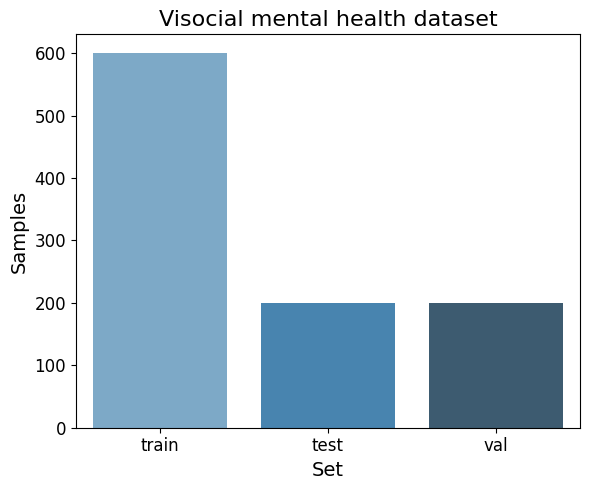

In [25]:
# Đếm số mẫu theo split
split_counts = df_all['split'].value_counts().reset_index()
split_counts.columns = ['split', 'count']

# Vẽ biểu đồ
plt.figure(figsize=(6, 5))
sns.barplot(data=split_counts, x='split', y='count', palette='Blues_d')
plt.title("Visocial mental health dataset", fontsize=16)
plt.xlabel("Set", fontsize=14)
plt.ylabel("Samples", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

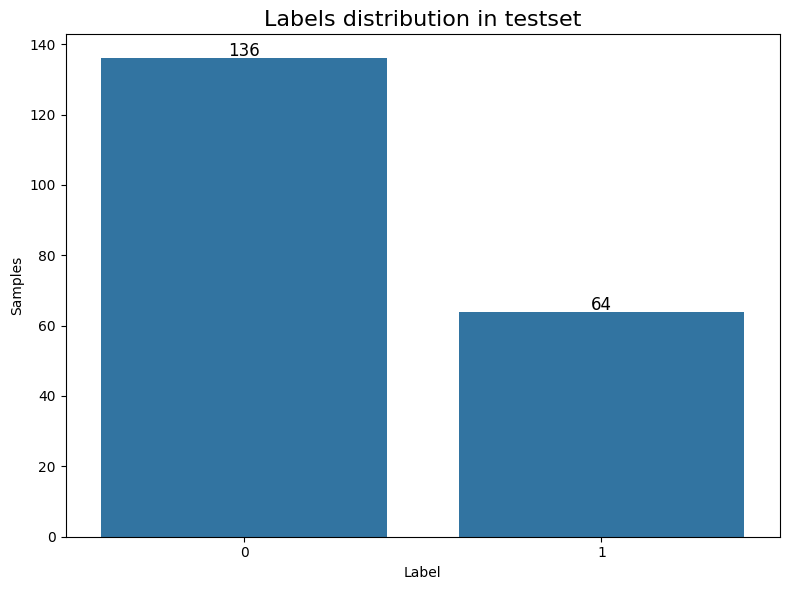

In [41]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df2, x='label')
plt.title("Labels distribution in testset", fontsize=16)
plt.xlabel("Label")
plt.ylabel("Samples")

# Thêm số lượng trên đầu mỗi cột
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.5,  # vị trí text
            int(height), ha="center", fontsize=12)

plt.tight_layout()
plt.show()


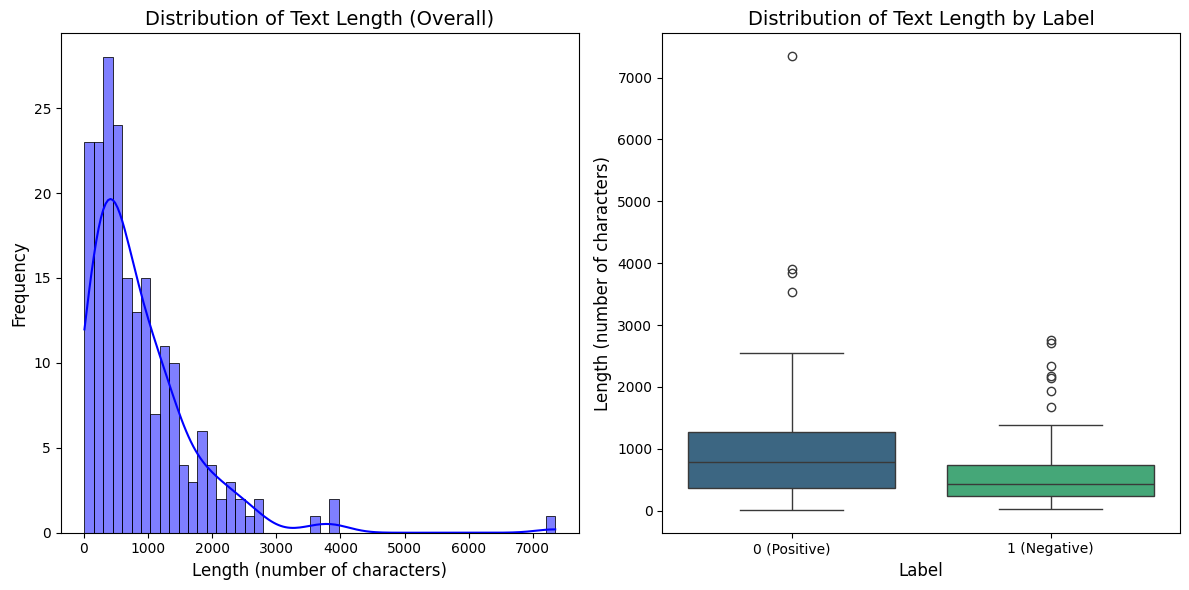


Descriptive statistics of text length by label:
       count        mean         std   min     25%    50%      75%     max
label                                                                     
0      136.0  968.176471  923.172837   9.0  361.75  787.5  1276.75  7349.0
1       64.0  660.203125  654.436173  29.0  237.25  429.5   741.00  2758.0


In [38]:
df2['text_length'] = df2['text'].fillna('').astype(str).apply(len)

plt.figure(figsize=(12, 6))

# Histogram of text length (overall)
plt.subplot(1, 2, 1)
sns.histplot(df2['text_length'], bins=50, kde=True, color='blue')
plt.title('Distribution of Text Length (Overall)', fontsize=14)
plt.xlabel('Length (number of characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Boxplot comparing text length by label
plt.subplot(1, 2, 2)
sns.boxplot(x='label', y='text_length', data=df2, hue='label', palette='viridis', legend=False)
plt.title('Distribution of Text Length by Label', fontsize=14)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Length (number of characters)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['0 (Positive)', '1 (Negative)'])

plt.tight_layout()
plt.show()

print("\nDescriptive statistics of text length by label:")
print(df2.groupby('label')['text_length'].describe())


In [40]:
df2.describe(include='all')


,text,label,split,text_length
count,200,200.000000,200,200.000000
unique,199,NaN,1,NaN
top,cuộc sống của tôi đang dần trở nên một cảm giá...,NaN,test,NaN
freq,2,NaN,200,NaN
mean,NaN,0.320000,NaN,869.625000
std,NaN,0.467647,NaN,857.023366
min,NaN,0.000000,NaN,9.000000
25%,NaN,0.000000,NaN,325.000000
50%,NaN,0.000000,NaN,642.000000
75%,NaN,1.000000,NaN,1196.750000


# SETUP API KEY FOR GEMINI

In [3]:
def setup_gemini_api_and_model(api_key_string: str, model_name: str):
    try:
        genai.configure(api_key=api_key_string)
        print("API key configured successfully.")
        model_instance = genai.GenerativeModel(model_name)
        print(f"Model initialized: {model_name}")
        return model_instance
    except Exception as e:
        print(f"Error while initializing: {e}")
        return None

In [ ]:
api_key_string = "API_KEY"
model_name = "gemini-2.0-flash"
model = setup_gemini_api_and_model(api_key_string, model_name)
if model is None:
    raise RuntimeError("Không thể khởi tạo model Gemini.")

API key configured successfully.
Model initialized: gemini-2.0-flash


In [5]:
response = model.generate_content("Hello")
print(response)

response:
GenerateContentResponse(
    done=True,
    iterator=None,
    result=protos.GenerateContentResponse({
      "candidates": [
        {
          "content": {
            "parts": [
              {
                "text": "Hello there! How can I help you today?\n"
              }
            ],
            "role": "model"
          },
          "finish_reason": "STOP",
          "avg_logprobs": -0.10872409560463646
        }
      ],
      "usage_metadata": {
        "prompt_token_count": 1,
        "candidates_token_count": 11,
        "total_token_count": 12
      },
      "model_version": "gemini-2.0-flash"
    }),
)


# PROMPTING

In [6]:
def load_and_select_prompt(csv_filepath: str,
                             prompt_name_column_in_csv: str,
                             prompt_text_column_in_csv: str,
                             selected_prompt_name_to_load: str):
    try:
        prompt_template_df = pd.read_csv(csv_filepath)
    except FileNotFoundError:
        print(f"LỖI: Không tìm thấy file CSV tại: {csv_filepath}")
        return None
    except Exception as e:
        print(f"LỖI khi đọc file CSV: {e}")
        return None

    if prompt_template_df.empty:
        print("LỖI: DataFrame chứa prompts rỗng sau khi đọc file CSV.")
        return None

    selected_prompt_row = prompt_template_df[prompt_template_df[prompt_name_column_in_csv] == selected_prompt_name_to_load]

    if selected_prompt_row.empty:
        print(f"LỖI: Không tìm thấy prompt có tên '{selected_prompt_name_to_load}' trong file CSV.")
        print("Các tên prompt có sẵn:", prompt_template_df[prompt_name_column_in_csv].tolist())
        return None
    else:
        current_prompt_text_content = selected_prompt_row[prompt_text_column_in_csv].iloc[0]
        print(f"Đã chọn prompt: '{selected_prompt_name_to_load}'")
        print(f"Nội dung prompt (200 ký tự đầu):\n------\n{current_prompt_text_content[:200]}...\n------")
        return current_prompt_text_content

In [7]:
csv_filepath_prompts = 'Prompting/prompt_templates.csv'
prompt_name_col_csv = 'prompt_engineering'
prompt_text_col_csv = 'text'
selected_prompt_name_to_run = "few_shot_2samples_cot_refine_v1_1"
current_prompt_text = load_and_select_prompt(
    csv_filepath=csv_filepath_prompts,
    prompt_name_column_in_csv=prompt_name_col_csv,
    prompt_text_column_in_csv=prompt_text_col_csv,
    selected_prompt_name_to_load=selected_prompt_name_to_run
)
if current_prompt_text is None:
    raise ValueError(f"Không thể tải prompt '{selected_prompt_name_to_run}'.")

Đã chọn prompt: 'few_shot_2samples_cot_refine_v1_1'
Nội dung prompt (200 ký tự đầu):
------
 "Phân loại bài đăng trên mạng xã hội Tiếng Việt sau đây liên quan đến sức khỏe tâm thần thành "Positive" hoặc "Negative". - "Positive": Không có dấu hiệu tiêu cực rõ ràng về vấn đề tâm lý cá nhân ngh...
------


# Gemini API Calls

## API Calls functions

In [8]:
# Hàm trả về kết quả nhãn và tokens cho 1 lần gọi API
def get_prediction(
    text_input: str,
    prompt_template: str,
    model,
    max_retries: int = 2, # số lần thử lại nếu lỗi 
    delay: int = 15        # delay
    ):
    try:
        prompt = prompt_template.format(text=text_input)
    except KeyError:
        print(f"Lỗi: Template prompt không chứa placeholder '{{text}}'. Kiểm tra file CSV.")
        return None, 0 # tokens lỗi trả về 0
    except Exception as format_err:
        print(f"Lỗi định dạng prompt: {format_err}")
        return None, 0

    retries = 0
    while retries < max_retries:
        try:
            safety_settings = {
                 genai.types.HarmCategory.HARM_CATEGORY_HARASSMENT: genai.types.HarmBlockThreshold.BLOCK_ONLY_HIGH,
                 genai.types.HarmCategory.HARM_CATEGORY_HATE_SPEECH: genai.types.HarmBlockThreshold.BLOCK_ONLY_HIGH,
                 genai.types.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: genai.types.HarmBlockThreshold.BLOCK_ONLY_HIGH,
                 genai.types.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: genai.types.HarmBlockThreshold.BLOCK_ONLY_HIGH,
            }
            response = model.generate_content(prompt, safety_settings=safety_settings)

            # Lấy tokens
            total_tokens = 0
            try:
                 # Kiểm tra xem usage_metadata có tồn tại và có dữ liệu không
                 if hasattr(response, 'usage_metadata') and response.usage_metadata:
                      prompt_tokens = response.usage_metadata.prompt_token_count
                      candidate_tokens = response.usage_metadata.candidates_token_count
                      # một số trường hợp API có sẵn số tokens
                      if hasattr(response.usage_metadata, 'total_token_count'):
                           total_tokens = response.usage_metadata.total_token_count
                      else:
                           total_tokens = prompt_tokens + candidate_tokens # tự tính nếu không có tổng 
                 else:
                      print(f"Cảnh báo: Không tìm thấy usage_metadata trong phản hồi cho: {text_input[:50]}...")
            except AttributeError as ae:
                 print(f"Cảnh báo: usage_metadata không có token count: {ae}")
            except Exception as token_err:
                 print(f"Lỗi khi lấy token count: {token_err}")

            prediction_text = response.text.strip().lower()

            if "negative" in prediction_text:
                return "Negative", total_tokens
            elif "positive" in prediction_text:
                return "Positive", total_tokens
            else:
                print(f"Cảnh báo: Định dạng output không mong muốn: '{response.text}'. Trả về None.")
                return None, total_tokens

        except genai.types.BlockedPromptException as bpe:
             print(f"Lỗi API: Prompt bị chặn. Lý do: {bpe}. Thử lại ({retries+1}/{max_retries})...")
             retries += 1
             time.sleep(delay * (retries + 1))
        except genai.types.StopCandidateException as sce:
             print(f"Lỗi API: Nội dung bị chặn trong phản hồi. Lý do: {sce}. Thử lại ({retries+1}/{max_retries})...")
             retries += 1
             time.sleep(delay * (retries + 1))
        except Exception as e:
            error_message = str(e)
            print(f"Lỗi API: {error_message}. Thử lại ({retries+1}/{max_retries})...")
            current_delay = delay
            if "429" in error_message or "503" in error_message: # Lỗi rate limit hoặc server
                current_delay = delay * (retries + 2)
                print(f"Lỗi rate limit/server, tăng delay lên {current_delay}s") #tăng dần them delay*(retries + 2) tới khi không lỗi nữa 
            retries += 1
            time.sleep(current_delay)

    print(f"Lỗi: Không thể lấy dự đoán cho văn bản '{text_input[:50]}...' sau {max_retries} lần thử.")
    return None, 0

In [9]:
# Hàm thực hiện gọi cho toàn bộ dữ liệu
def api_calls_for_dataset(
    data_df: pd.DataFrame,
    prompt_text_template: str,
    gemini_model,
    label_mapping: dict,
    current_selected_prompt_name: str,
    api_call_delay: int = 20
):
    """
    Thực hiện gọi API Gemini cho từng dòng dữ liệu và thu thập kết quả.

    Args:
        data_df: DataFrame chứa dữ liệu cần đánh giá (cột 'text', 'label').
        prompt_text_template: Template của prompt hiện tại.
        gemini_model: Đối tượng model Gemini đã khởi tạo.
        label_mapping: Dictionary để ánh xạ nhãn chuỗi sang số (ví dụ: {"Positive": 0, "Negative": 1}).
        current_selected_prompt_name: Tên của prompt đang được đánh giá (dùng cho tqdm).
        api_call_delay: Thời gian nghỉ (giây) giữa các lần gọi API.

    Returns:
        Tuple chứa:
            - true_labels_for_metrics (list): Danh sách các nhãn thực tế (dạng số) cho các dự đoán hợp lệ.
            - predicted_labels_for_metrics (list): Danh sách các nhãn dự đoán (dạng số) hợp lệ.
            - all_predictions_for_df (list): Danh sách tất cả các dự đoán (dạng số hoặc None) cho mỗi dòng trong data_df.
            - token_counts (list): Danh sách số token sử dụng cho các lần gọi API thành công.
    """
    true_labels_for_metrics = []
    predicted_labels_for_metrics = []
    all_predictions_for_df = [None] * len(data_df)
    token_counts = []

    print(f"Đánh giá trên {len(data_df)} mẫu sử dụng model {gemini_model.model_name}...")

    for index, row in tqdm(data_df.iterrows(), total=len(data_df), desc=f"Đánh giá {current_selected_prompt_name}"):
        text_to_predict = row['text']
        true_label_int = row['label']

        if not isinstance(text_to_predict, str):
            print(f"Cảnh báo: Dữ liệu text ở dòng {index} không phải string ('{text_to_predict}'). Bỏ qua.")
            all_predictions_for_df[index] = None
            continue

        predicted_label_str, tokens_used = get_prediction(
            text_input=text_to_predict,
            prompt_template=prompt_text_template,
            model=gemini_model 
        )

        predicted_label_int_current = label_mapping.get(predicted_label_str)
        all_predictions_for_df[index] = predicted_label_int_current

        if predicted_label_int_current is not None:
            true_labels_for_metrics.append(true_label_int)
            predicted_labels_for_metrics.append(predicted_label_int_current)
            if tokens_used > 0:
                token_counts.append(tokens_used)
        else:
            print(f"Bỏ qua dòng {index} khi tính metrics do lỗi dự đoán/định dạng.")

        time.sleep(api_call_delay)

    return true_labels_for_metrics, predicted_labels_for_metrics, all_predictions_for_df, token_counts

In [10]:
def evaluate_model_predictions(
    true_labels: list,
    predicted_labels: list,
    inverse_label_mapping: dict,
    current_selected_prompt_name: str,
    token_counts_list: list
):
    """
    Tính toán và hiển thị các chỉ số đánh giá mô hình.

    Args:
        true_labels: Danh sách các nhãn thực tế (dạng số).
        predicted_labels: Danh sách các nhãn dự đoán (dạng số).
        inverse_label_mapping: Dictionary để ánh xạ nhãn số về chuỗi (ví dụ: {0: "Positive", 1: "Negative"}).
        current_selected_prompt_name: Tên của prompt đang được đánh giá.
        token_counts_list: Danh sách số token đã sử dụng.

    Returns:
        Dictionary chứa các chỉ số đánh giá.
    """
    print(f"____ Kết quả cho Prompt: {current_selected_prompt_name} ({len(true_labels)} mẫu được dự đoán thành công) ____")

    evaluation_metrics = {}
    average_tokens = 0
    if token_counts_list:
        average_tokens = sum(token_counts_list) / len(token_counts_list)
        print(f"Số token trung bình mỗi lần gọi API: {average_tokens:.2f}")
    elif true_labels:
        print("Không thể tính token trung bình (không có dữ liệu token hoặc lỗi).")
    else:
        print("Không có lần gọi API thành công nào để tính token trung bình.")
    evaluation_metrics['average_tokens'] = average_tokens

    if not true_labels:
        print("Không có dự đoán hợp lệ nào được thực hiện cho prompt này. Không thể tính toán metrics.")
        return evaluation_metrics

    unique_int_labels = sorted(list(set(true_labels) | set(predicted_labels)))
    target_names = [inverse_label_mapping.get(i, f"Unknown({i})") for i in unique_int_labels]

    print("Báo cáo Phân loại:")
    report = classification_report(true_labels, predicted_labels, labels=unique_int_labels, target_names=target_names, digits=4, zero_division=0)
    print(report)
    evaluation_metrics['classification_report'] = report

    accuracy = accuracy_score(true_labels, predicted_labels)
    balanced_acc = balanced_accuracy_score(true_labels, predicted_labels)
    f1_macro = f1_score(true_labels, predicted_labels, average='macro', labels=unique_int_labels, zero_division=0)
    f1_weighted = f1_score(true_labels, predicted_labels, average='weighted', labels=unique_int_labels, zero_division=0)

    evaluation_metrics['accuracy'] = accuracy
    evaluation_metrics['balanced_accuracy'] = balanced_acc
    evaluation_metrics['f1_macro'] = f1_macro
    evaluation_metrics['f1_weighted'] = f1_weighted

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"F1 Score (Macro): {f1_macro:.4f}")
    print(f"F1 Score (Weighted): {f1_weighted:.4f}")

    print("Confusion matrix:")
    if len(unique_int_labels) > 1:
        cm = confusion_matrix(true_labels, predicted_labels, labels=unique_int_labels)
        cm_df = pd.DataFrame(cm, index=[f"Thực tế {inverse_label_mapping.get(l, l)}" for l in unique_int_labels],
                               columns=[f"Dự đoán {inverse_label_mapping.get(l, l)}" for l in unique_int_labels])
        print(cm_df)
        evaluation_metrics['confusion_matrix_df'] = cm_df
    elif len(unique_int_labels) == 1:
        print(f"Chỉ có một lớp ({inverse_label_mapping.get(unique_int_labels[0], unique_int_labels[0])}) trong các dự đoán hợp lệ.")
    else:
        print("Không có đủ dữ liệu hợp lệ để tạo ma trận nhầm lẫn.")

    return evaluation_metrics

In [11]:
def save_results_to_csv_file(
    original_data_df: pd.DataFrame,
    all_predictions_list: list,
    current_selected_prompt_name: str,
    columns_to_save: list = ['text', 'label']
):
    """
    Thêm cột dự đoán vào DataFrame và lưu kết quả ra file CSV.

    Args:
        original_data_df: DataFrame gốc.
        all_predictions_list: Danh sách tất cả các dự đoán (có thể chứa None).
        current_selected_prompt_name: Tên của prompt đang được đánh giá.
        columns_to_save: Danh sách tên các cột từ DataFrame gốc muốn lưu cùng cột dự đoán.

    Returns:
        Tên file đã lưu nếu thành công, None nếu thất bại.
        DataFrame gốc (có thể đã được xóa cột dự đoán tạm thời).
    """
    prediction_col_name = f'pred_{current_selected_prompt_name}'
    # Tạo bản sao để không làm thay đổi DataFrame gốc
    data_with_predictions_df = original_data_df.copy()

    if len(all_predictions_list) == len(data_with_predictions_df):
        data_with_predictions_df[prediction_col_name] = all_predictions_list

        safe_prompt_name = re.sub(r'[\\/*?:"<>|]', '_', current_selected_prompt_name)
        output_filename = f'gemini_labeled_{safe_prompt_name}.csv'

        # Đảm bảo các cột trong columns_to_save tồn tại trong data_with_predictions_df
        final_columns_to_save = [col for col in columns_to_save if col in data_with_predictions_df.columns]
        if prediction_col_name not in final_columns_to_save:
             final_columns_to_save.append(prediction_col_name)

        try:
            data_to_actually_save = data_with_predictions_df[final_columns_to_save]
            data_to_actually_save.to_csv(output_filename, index=False)

            print(f"Đã lưu DataFrame với dự đoán vào file: {output_filename}")
            print("Kiểm tra DataFrame kết quả (5 dòng đầu):\n", data_to_actually_save.head())
            print("Thông tin DataFrame kết quả:")
            data_to_actually_save.info()
            return output_filename
        except Exception as e:
            print(f"Lỗi khi lưu file dự đoán: {e}")
            return None
    else:
        print(f"LỖI: Số lượng dự đoán ({len(all_predictions_list)}) không khớp với số hàng trong data ({len(data_with_predictions_df)}). Không thêm cột và không lưu file.")
        return None

In [12]:
def main_evaluation_orchestrator(
    gemini_model_instance,
    data_for_evaluation_df: pd.DataFrame,
    prompt_name_to_run: str,
    prompt_text_to_use: str
):
    """
    Điều phối toàn bộ quá trình đánh giá cho một prompt.
    """
    # Kiểm tra các input cần thiết
    if gemini_model_instance is None:
         raise ValueError("Biến 'gemini_model_instance' của Gemini chưa được định nghĩa hoặc None.")
    if data_for_evaluation_df is None or data_for_evaluation_df.empty:
         raise ValueError("Biến 'data_for_evaluation_df' chứa DataFrame rỗng hoặc None.")
    if not prompt_name_to_run or not prompt_text_to_use:
         raise ValueError("Tên prompt hoặc nội dung prompt không được cung cấp.")

    print(f"{'='*20} Bắt đầu đánh giá cho prompt: {prompt_name_to_run} {'='*20}")
    print(f"Sử dụng template prompt (200 ký tự đầu):\n____\n{prompt_text_to_use[:200]}...\n_____")

    # Định nghĩa ánh xạ nhãn
    label_map_config = {"Positive": 0, "Negative": 1}
    inv_label_map_config = {v: k for k, v in label_map_config.items()}

    # 1. Gọi API
    true_labels, predicted_labels, all_predictions, tokens = api_calls_for_dataset(
        data_df=data_for_evaluation_df,
        prompt_text_template=prompt_text_to_use,
        gemini_model=gemini_model_instance,
        label_mapping=label_map_config,
        current_selected_prompt_name=prompt_name_to_run,
        api_call_delay=10
    )

    print(f"\nĐánh giá cho prompt '{prompt_name_to_run}' hoàn tất.")

    # 2. Đánh giá
    metrics_results = evaluate_model_predictions(
        true_labels=true_labels,
        predicted_labels=predicted_labels,
        inverse_label_mapping=inv_label_map_config,
        current_selected_prompt_name=prompt_name_to_run,
        token_counts_list=tokens
    )

    # 3. Lưu file
    # Tạo một bản sao của DataFrame gốc để truyền vào hàm lưu, để tránh thay đổi `data` toàn cục
    df_copy_for_saving = data_for_evaluation_df.copy()
    saved_file_name = save_results_to_csv_file(
        original_data_df=df_copy_for_saving, # Truyền bản sao
        all_predictions_list=all_predictions,
        current_selected_prompt_name=prompt_name_to_run,
        columns_to_save=['text', 'label'] # Các cột gốc muốn giữ
    )

    print(f"{'='*20} Kết thúc đánh giá cho prompt: {prompt_name_to_run} {'='*20}")
    return metrics_results, saved_file_name

## Run experiments

In [14]:
evaluation_metrics, name_of_saved_csv = main_evaluation_orchestrator(
    gemini_model_instance=model,
    data_for_evaluation_df=df2,
    prompt_name_to_run=selected_prompt_name_to_run,
    prompt_text_to_use=current_prompt_text
)

==================== Bắt đầu đánh giá cho prompt: few_shot_2samples_cot_refine_v1_1 ====================
Sử dụng template prompt (200 ký tự đầu):
____
 "Phân loại bài đăng trên mạng xã hội Tiếng Việt sau đây liên quan đến sức khỏe tâm thần thành "Positive" hoặc "Negative". - "Positive": Không có dấu hiệu tiêu cực rõ ràng về vấn đề tâm lý cá nhân ngh...
_____
Đánh giá trên 200 mẫu sử dụng model models/gemini-2.0-flash...


Đánh giá few_shot_2samples_cot_refine_v1_1:   0%|          | 0/200 [00:00<?, ?it/s]


Đánh giá cho prompt 'few_shot_2samples_cot_refine_v1_1' hoàn tất.
____ Kết quả cho Prompt: few_shot_2samples_cot_refine_v1_1 (200 mẫu được dự đoán thành công) ____
Số token trung bình mỗi lần gọi API: 1844.71
Báo cáo Phân loại:
              precision    recall  f1-score   support

    Positive     0.9216    0.6912    0.7899       136
    Negative     0.5714    0.8750    0.6914        64

    accuracy                         0.7500       200
   macro avg     0.7465    0.7831    0.7406       200
weighted avg     0.8095    0.7500    0.7584       200

Accuracy: 0.7500
Balanced Accuracy: 0.7831
F1 Score (Macro): 0.7406
F1 Score (Weighted): 0.7584
Confusion matrix:
                  Dự đoán Positive  Dự đoán Negative
Thực tế Positive                94                42
Thực tế Negative                 8                56
Đã lưu DataFrame với dự đoán vào file: gemini_labeled_few_shot_2samples_cot_refine_v1_1.csv
Kiểm tra DataFrame kết quả (5 dòng đầu):
                                      

In [ ]:
if name_of_saved_csv: # Chỉ xóa nếu việc lưu file thành công
    prediction_column_to_drop = f'pred_{selected_prompt_name_to_run}'
    if prediction_column_to_drop in data.columns:
        data.drop(columns=[prediction_column_to_drop], inplace=True)
        print(f"Đã xóa cột '{prediction_column_to_drop}' khỏi DataFrame 'data' để chuẩn bị cho lần chạy sau.")
    else:
        print(f"Cảnh báo: Cột '{prediction_column_to_drop}' không tìm thấy trong DataFrame 'data' để xóa.")

Cảnh báo: Cột 'pred_few_shot_2samples_cot_v1' không tìm thấy trong DataFrame 'data' để xóa.


## Eval

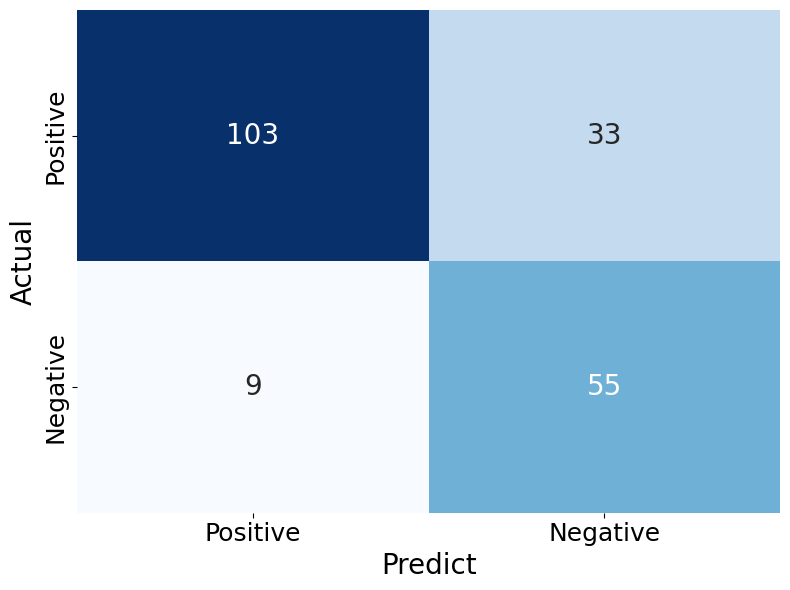

In [ ]:
# Confusion matrix
conf_matrix = np.array([[103, 33],
                        [9, 55]])

labels = ["Positive", "Negative"]

fig, ax = plt.subplots(figsize=(8, 6))

# Vẽ heatmap với cỡ chữ lớn
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=labels, yticklabels=labels, ax=ax,
            annot_kws={"fontsize": 20})

# Thiết lập tiêu đề và nhãn với cỡ chữ lớn
ax.set_xlabel("Predict", fontsize=20)
ax.set_ylabel("Actual", fontsize=20)

# Cỡ chữ trục
ax.tick_params(labelsize=18)

plt.tight_layout()
plt.show()


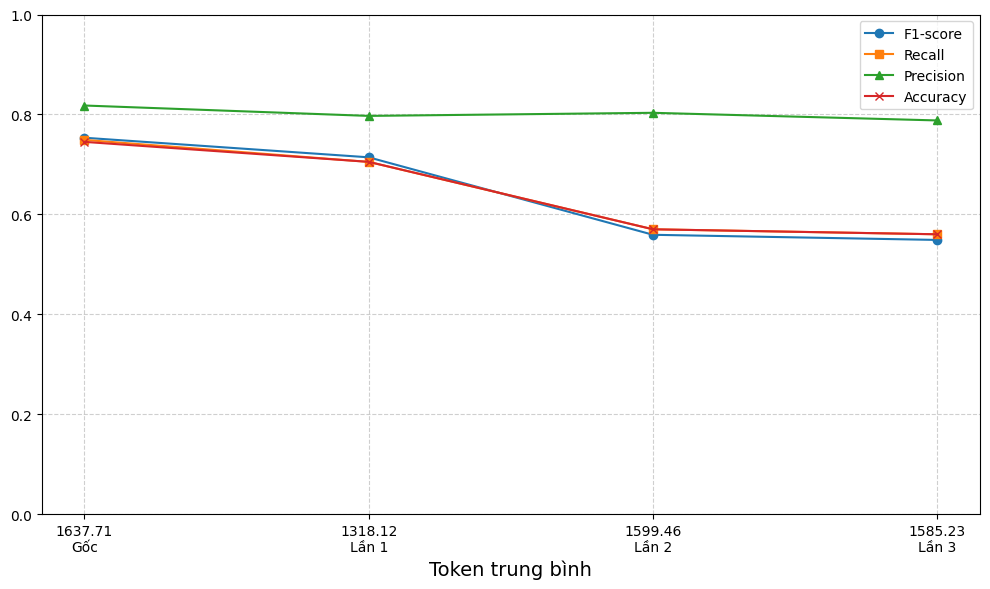

In [ ]:
# Dữ liệu
labels = [
    "1637.71\nGốc",
    "1318.12\nLần 1",
    "1599.46\nLần 2",
    "1585.23\nLần 3"
]

f1_scores = [0.7533, 0.7141, 0.5590, 0.5487]
recalls =   [0.7490, 0.7049, 0.5700, 0.5600]
precisions = [0.8178, 0.7970, 0.8032, 0.7879]
accuracies = [0.7450, 0.7050, 0.5700, 0.5600]

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(labels, f1_scores, marker='o', label="F1-score")
plt.plot(labels, recalls, marker='s', label="Recall")
plt.plot(labels, precisions, marker='^', label="Precision")
plt.plot(labels, accuracies, marker='x', label="Accuracy")

# Tùy chỉnh biểu đồ
plt.xlabel("Token trung bình", fontsize=14)
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


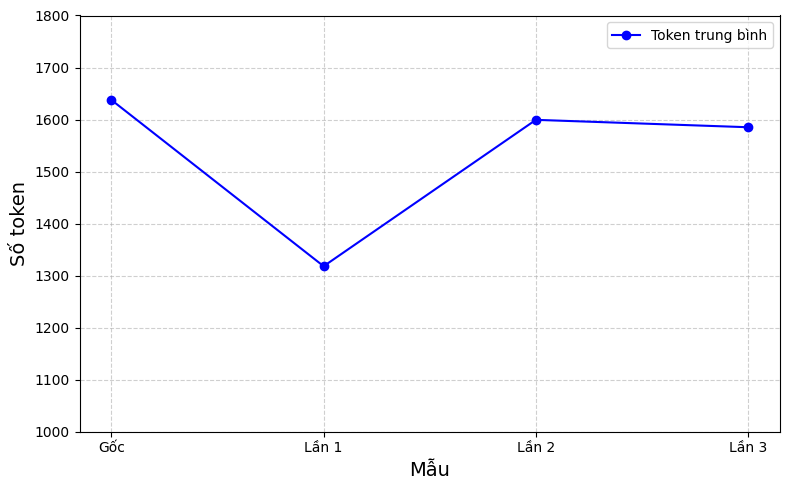

In [ ]:
# Dữ liệu token
tokens = [1637.71, 1318.12, 1599.46, 1585.23]
labels = ["Gốc", "Lần 1", "Lần 2", "Lần 3"]

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
plt.plot(labels, tokens, marker='o', linestyle='-', color='blue', label="Token trung bình")

# Tùy chỉnh trục
plt.xlabel("Mẫu", fontsize=14)
plt.ylabel("Số token", fontsize=14)
plt.ylim(1000, 1800)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
